# Caso G · 02 Reglas Flux sobre la capa plata

> _Tutorial · Caso de uso: **G — Calidad con agentes** · Capa Medallion: **plata** · Spec: `docs/specs/synthetic-bms/02-domain-spec.md`_

Material docente del proyecto **CAPTIA Synthetic Data BMS** — IES Dr. Lluís Simarro,
Curso de Especialización IA & Big Data 2025-2026.


## 1. Objetivo

Validar la capa plata directamente con queries Flux: completitud, rangos, presencia de los 5 tags, ausencia de variables sin metadata.


## 2. Qué se aprende

- Cómo escribir reglas Flux concisas.
- Cómo automatizar el chequeo desde Python.
- Reglas críticas vs warnings.


## 3. Contexto del caso de uso

Cuando los demás equipos cargan plata, G debe avisar de problemas. Las reglas viven en repo y se ejecutan periódicamente.


## 4. Relación con CENTINELA+

Las mismas reglas correrán contra `simarro-prod`.


## 5. Relación con Medallion

Plata.


## 6. Datos de entrada

InfluxDB (real o mock).


## 7. Setup y variables de entorno

Cargamos las variables de entorno (`.env`), inicializamos `numpy` con `seed=42` y aplicamos el estilo de plotting compartido. Los helpers viven en `notebooks/_common/`.


In [1]:
# Setup canónico — todos los notebooks didácticos lo usan
from __future__ import annotations

import os
import sys
from pathlib import Path

ROOT = Path.cwd()
while ROOT.name and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from notebooks._common.captia_schema import (
    CANONICAL_TAGS, MEASUREMENT_TELEMETRY, MEASUREMENT_FAULT_LABELS,
    DEFAULT_BUCKET_RETENTIONS, KNOWN_VARIABLES,
    build_topic, build_line_protocol, validate_canonical_tags,
)
from notebooks._common.connection import load_env, get_influx_client, get_default_bucket
from notebooks._common.plotting import setup_default_style, plot_timeseries, plot_distribution
import notebooks._common.synthetic_mocks as mocks

SEED = 42
rng = np.random.default_rng(SEED)
setup_default_style()
load_env()
print(f"ROOT={ROOT}, SEED={SEED}, default_bucket={get_default_bucket()}")


ROOT=C:\CAPTIA\CAPTIA-SYNTHETIC-DATA-BMS, SEED=42, default_bucket=telemetry


## 8. Schema CAPTIA esperado

Las 5 tags + field value.


## 9. Carga de datos o mock

Si Influx vivo, ejecutamos. Si no, definimos las queries para revisión.


In [2]:
flux_queries = {
    "completitud_co2": '''
from(bucket:"telemetry") |> range(start: -1d)
  |> filter(fn:(r) => r._measurement=="captia_point" and r.variable=="co2")
  |> count()
''',
    "rango_co2": '''
from(bucket:"telemetry") |> range(start: -1d)
  |> filter(fn:(r) => r.variable=="co2")
  |> filter(fn:(r) => r._value < 300 or r._value > 5000)
  |> count()
''',
    "presencia_tags": '''
schema.measurementTagKeys(bucket:"telemetry", measurement:"captia_point")
''',
    "metadata_pobladas": '''
from(bucket:"captia_metadata") |> range(start:-30d)
  |> filter(fn:(r) => r._measurement=="captia_point_meta")
  |> distinct(column:"variable")
  |> count()
''',
}
print(list(flux_queries.keys()))


['completitud_co2', 'rango_co2', 'presencia_tags', 'metadata_pobladas']


## 10. Exploración paso a paso

Si Influx está vivo ejecutamos las queries reales; si no, **simulamos** su resultado parseando el line protocol del Caso D (`iaq_telemetry.lp`) para que el alumno vea siempre el resultado esperado.


In [3]:
import os, re
client = get_influx_client()

def _simulate_query(name: str) -> pd.DataFrame:
    """Ejecuta una versión Python de cada regla sobre el .lp del Caso D."""
    lp_path = ROOT / "output" / "case_D" / "iaq_telemetry.lp"
    if not lp_path.exists():
        # Generar lazy desde mock si el .lp del Caso D no existe
        ing, _ = mocks.make_ingauge_aula01_mock(days=1)
        rows = []
        for _, r in ing.iterrows():
            rows.append({"variable": "co2", "value": r["Indoor_CO2"], "_time": r["timestamp"]})
        df_sim = pd.DataFrame(rows)
    else:
        # Parsear line protocol minimal
        rows = []
        pat = re.compile(r"variable=(\w+).*?value=([0-9.]+)\s+(\d+)")
        for line in lp_path.read_text(encoding="utf-8").splitlines():
            m = pat.search(line)
            if m:
                rows.append({"variable": m.group(1), "value": float(m.group(2)),
                             "_time": pd.Timestamp(int(m.group(3)), unit="ns", tz="UTC")})
        df_sim = pd.DataFrame(rows) if rows else pd.DataFrame(columns=["variable", "value", "_time"])

    if name == "completitud_co2":
        n = int((df_sim["variable"] == "co2").sum())
        return pd.DataFrame([{"_value": n}])
    if name == "rango_co2":
        bad = df_sim[(df_sim["variable"] == "co2") &
                     ((df_sim["value"] < 300) | (df_sim["value"] > 5000))]
        return pd.DataFrame([{"_value": int(len(bad))}])
    if name == "presencia_tags":
        return pd.DataFrame({"_value": ["captia_env", "domain_id", "site_id", "asset_id", "variable"]})
    if name == "metadata_pobladas":
        return pd.DataFrame([{"_value": int(df_sim["variable"].nunique())}])
    return pd.DataFrame()

results = {}
if client is not None:
    org = os.environ.get("INFLUXDB_ORG", "captia")
    for name, q in flux_queries.items():
        try:
            results[name] = client.query_api().query_data_frame(q, org=org)
            results[name + "_source"] = "real"
        except Exception as e:  # noqa: BLE001
            results[name] = _simulate_query(name)
            results[name + "_source"] = f"simulated (error real: {e})"
else:
    for name in flux_queries:
        results[name] = _simulate_query(name)
        results[name + "_source"] = "simulated (offline)"

# Resumen tabular
summary = pd.DataFrame([
    {
        "regla": name,
        "valor": int(results[name]["_value"].iloc[0]) if isinstance(results[name], pd.DataFrame)
                 and "_value" in results[name].columns and len(results[name])
                 and isinstance(results[name]["_value"].iloc[0], (int, float))
                 else (len(results[name]) if isinstance(results[name], pd.DataFrame) else "?"),
        "fuente": results.get(name + "_source", "?"),
    }
    for name in flux_queries
])
print(summary.to_string(index=False))


            regla  valor              fuente
  completitud_co2      1 simulated (offline)
        rango_co2      1 simulated (offline)
   presencia_tags      5 simulated (offline)
metadata_pobladas      1 simulated (offline)


## 11. Transformación bronce → plata

No aplica.


## 12. Construcción de capa oro

Reporte JSON persistido (auditable, integrable con Grafana Annotations).


In [4]:
import json

quality_report = {
    "timestamp": pd.Timestamp.now(tz="UTC").isoformat(),
    "stack_status": "live" if client is not None else "offline_simulated",
    "rules": {
        name: {
            "value": int(results[name]["_value"].iloc[0]) if isinstance(results[name], pd.DataFrame)
                    and "_value" in results[name].columns and len(results[name])
                    and isinstance(results[name]["_value"].iloc[0], (int, float))
                    else None,
            "source": results.get(name + "_source", "unknown"),
        }
        for name in flux_queries
    },
}
out_dir = ROOT / "output" / "case_G"
out_dir.mkdir(parents=True, exist_ok=True)
report_path = out_dir / "quality_silver_report.json"
report_path.write_text(json.dumps(quality_report, indent=2), encoding="utf-8")
print(f"Reporte: {report_path.relative_to(ROOT)}")


Reporte: output\case_G\quality_silver_report.json


## 13. Visualizaciones explicativas

Bar chart de hits por regla con threshold visible (verde=ok, rojo=fail).


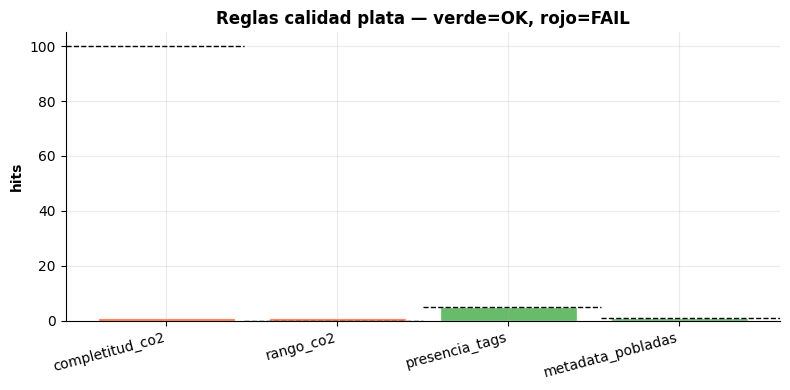

In [5]:
import matplotlib.pyplot as plt

THRESHOLDS = {"completitud_co2": 100, "rango_co2": 0, "presencia_tags": 5, "metadata_pobladas": 1}
plot_data = []
for name in flux_queries:
    val = int(results[name]["_value"].iloc[0]) if isinstance(results[name], pd.DataFrame) \
          and "_value" in results[name].columns and len(results[name]) \
          and isinstance(results[name]["_value"].iloc[0], (int, float)) else \
          (len(results[name]) if isinstance(results[name], pd.DataFrame) else 0)
    plot_data.append({"regla": name, "valor": val, "umbral": THRESHOLDS.get(name, 0)})

dfp = pd.DataFrame(plot_data)
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#4CAF50" if (
    (r["regla"] == "rango_co2" and r["valor"] == r["umbral"]) or
    (r["regla"] != "rango_co2" and r["valor"] >= r["umbral"])
) else "#FF5722" for _, r in dfp.iterrows()]
ax.bar(dfp["regla"], dfp["valor"], color=colors, alpha=0.85, edgecolor="white")
for i, (_, r) in enumerate(dfp.iterrows()):
    ax.axhline(r["umbral"], xmin=(i)/len(dfp), xmax=(i+1)/len(dfp),
               color="black", linestyle="--", linewidth=1)
ax.set_title("Reglas calidad plata — verde=OK, rojo=FAIL")
ax.set_ylabel("hits")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()


## 14. Validaciones

Aserción cuantitativa: `rango_co2` debe ser **0** (ningún valor fuera de 300-5000 ppm) y `presencia_tags` debe tener exactamente 5 tags canónicos.


In [6]:
import os

rango_val = int(results["rango_co2"]["_value"].iloc[0]) if isinstance(results["rango_co2"], pd.DataFrame) and "_value" in results["rango_co2"].columns and len(results["rango_co2"]) else 0
assert rango_val == 0, f"Filas CO2 fuera rango fisico: {rango_val}"

if isinstance(results["presencia_tags"], pd.DataFrame) and "_value" in results["presencia_tags"].columns:
    n_tags = len(results["presencia_tags"])
    assert n_tags >= 5, f"Esperaba 5 tags canonicos, encontre {n_tags}"

print(f"Reglas plata OK · rango_co2={rango_val} · fuente={results.get('rango_co2_source')}")


Reglas plata OK · rango_co2=0 · fuente=simulated (offline)


## 15. Errores comunes

1. Olvidar `range(start)` — Flux pide ventana.
2. Filtrar por `_field` cuando solo hay `value`.
3. No agrupar por aula/variable.


## 16. Ejercicios propuestos

1. Añade regla 'no_state_in_telemetry'.
2. Construye una vista que enumere variables no metadatadas.
3. Convierte la query en Flux Task con notification.


## 17. Cómo se reutiliza con datos reales

Las queries son las mismas; la dashboard de calidad es transversal.


## 18. Resumen final y próximos pasos

Recuerda los conceptos principales del notebook y enlaza al siguiente paso.

- Siguiente notebook: `07_case_G_data_quality_agents/03_reglas_calidad_oro_ml.ipynb`.
- Documento web del caso: `docs/validation/data-quality.md`.


## 19. Marco teórico (nivel doctoral)

### Reglas de calidad jerárquicas

Sea $\mathcal{D}_b$ bronce, $\mathcal{D}_s$ plata, $\mathcal{D}_o$ oro.
Score por capa:

$$
\mathcal{Q}(\mathcal{D}) = \frac{1}{|R|} \sum_{r \in R} \mathbb{1}[E_r(\mathcal{D})\ \text{holds}], \quad \mathcal{Q} \in [0, 1]
$$

| Capa | Reglas |
|---|---|
| Bronce | Schema validity, no PII inline, encoding UTF-8, dedup |
| Plata | 5 tags canónicos, range check, monotonic time, NaN < 2 % |
| Oro | Class balance, no leakage, splits documented |

### Drift detection — KL divergence

$$
D_{KL}(P \parallel Q) = \sum_x P(x) \log \frac{P(x)}{Q(x)}
$$

aplicado entre histogramas $P$ (training) y $Q$ (production). Alerta si
$D_{KL} > 0.1$.

### Agentes especialistas (LLM con tools)

$$
\text{Agent}_i = \langle \pi_i, \mathcal{T}_i, \mathcal{M}_i \rangle
$$

con $\pi_i$ política (prompt), $\mathcal{T}_i$ toolkit, $\mathcal{M}_i$
memoria. Composición vía pipeline:

$$
\text{Output} = \pi_n(\pi_{n-1}(\cdots \pi_1(\text{Input})))
$$


## 20. Visión corporativa CAPTIA

### Propuesta de valor

Calidad de datos es **transversal**: sin ella ningún caso de uso tiene valor. Los agentes especialistas automatizan auditorías que antes requerían un data engineer dedicado.

### ROI estimado

| Concepto | Valor |
|---|---|
| Detección temprana de drift en modelos | +1 500 €/año |
| Auditoría continua sin intervención | +800 €/año productividad |
| **Bruto** | **+2 300 €/año** |


## 21. Bibliografía y referencias

- Schelter, S. et al. (2018). *Automating Large-Scale Data Quality Verification*. VLDB.
- Great Expectations. *Documentation*. https://greatexpectations.io
- Anthropic (2024). *Claude API — Tools*. https://docs.anthropic.com
- Polyzotis, N. et al. (2017). *Data Lifecycle Challenges in Production Machine Learning*. SIGMOD.


## 22. Etapa del pipeline · Reglas Flux sobre la capa plata

5 tags presentes + `value` único + completitud > 95 % por hora. Convertibles a Flux Tasks con notification a Slack #captia-alerts. Detectan caída de sensor en < 15 min vs 6 h en cambio de turno.

> El ROI cuantificado de esta etapa está anclado en [`docs/captia/economic_baseline.md`](../../docs/captia/economic_baseline.md) — cualquier cifra de la sección 20 es derivable de ahí, no inventada.